# Classification with K-nearest neighbors 

In [1]:
#K should be an odd number and superior to the number of groups 
#confidence is for one guess
#accuracy is for the entire model
#Class: 2 for benign, 4 for malignant (11e colonne)

In [2]:
import numpy as np
from sklearn import preprocessing, model_selection, neighbors
import pandas as pd

df=pd.read_csv('breast-cancer-wisconsin.data', encoding='ANSI')
df.replace('?', -99999, inplace=True) #replace the missing data with -99999
df.drop(['id'], 1, inplace=True) #drop the id column to avoid outliers

X=np.array(df.drop(['class'], 1))
print(df.columns)
y=df['class']

X_train, X_test, y_train, y_test=model_selection.train_test_split(X,y, test_size=0.2)

clf=neighbors.KNeighborsClassifier(n_jobs=-1)
clf.fit(X_train, y_train) #train it with the training data

accuracy=clf.score(X_test, y_test)

print (accuracy)

Index(['clump_thickness', 'uniformity_of_cell_size',
       'uniformity_of_cell_shape', 'marginal_adhesion',
       'single_epithelial_cell_size', 'bare_nuclei', 'bland_chromatin',
       'normal_nucleoli', 'mitoses', 'class'],
      dtype='object')
0.9642857142857143


In [3]:
example_measures=np.array([4,2,1,1,1,2,3,2,1])
example_measures=example_measures.reshape(1, -1)

#to reshape a list of two list: reshape(2,-1)
#to reshape a list of a random number of lists: reshape(len(example_measures, -1))

prediction=clf.predict(example_measures)
print(prediction)

[2]


# Euclidian distance 

In [4]:
#racine(Sigma sur i (pi-qi)²) c'est la distance euclidienne de base
plot1=[2,3]
plot2=[1,5]
def squaredEuclideanDistance(x1,x2):
    d=0
    for i in range(len(x1)):
        d+=(x1[i]-x2[i])**2
    return d

## Creating our own KNN

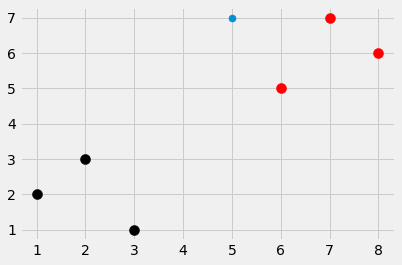

r


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import warnings
from collections import Counter
style.use('fivethirtyeight')

dataset={'k': [[1,2],[2,3], [3,1]], 'r': [[6,5],[7,7], [8,6]]} #creating classes k and r and their attributes in a dictionary{}
new_features=[5,7]

for i in dataset:
    for ii in dataset[i]:
        plt.scatter(ii[0], ii[1], s=100, color=i)
        
# OR: [[plt.scatter(ii[0],ii[1], s=100, color=i) for ii in dataset[i]] for i in dataset]

plt.scatter(new_features[0], new_features[1], s=50)
plt.show()

def KNN(data, predict, k=3):
    if len(data)>=k:
        warnings.warn('k is set to a value inferior to the total number of groups!')
    distances=[]
    for group in data:
        for features in data[group]:
            distances.append([np.linalg.norm(np.array(features)-np.array(predict)), group]) #distance euclidienne 
                             # ou alors (np.array(features)-np.array(predict))**2 which is slower
    votes=[i[1]for i in sorted(distances)[:k]]
    #print(Counter(votes).most_common(1)) prints (result, number of votes in favor of the result)
    vote_result=Counter(votes).most_common(1)[0][0]
    confidence=Counter(votes).most_common(1)[0][1]/k
    return vote_result, confidence

result= KNN(dataset, new_features,k=3)[0]
print(result)

In [6]:
import random

df=pd.read_csv('breast-cancer-wisconsin.data', encoding='ANSI')
df.replace('?', -99999, inplace=True) #replace the missing data with -99999
df.drop(['id'], 1, inplace=True) #drop the id column to avoid outliers

full_data=df.astype(float).values.tolist()# so that '4' becomes 4.0 string to float

#Here is a somewhat cleaner way to avoid the issue where one column was parsed as string type:
#df = pd.read_csv('breast_cancer_wisconsin.csv', na_values='?', header=0).fillna(-99999).drop('id', axis=1)

#full data is a list of lists
#shuffling the data:
random.shuffle(full_data)

test_size=0.2
train_set={2:[], 4:[]}
test_set={2:[], 4:[]}
train_data=full_data[:-int(test_size*len(full_data))]
test_data=full_data[-int(test_size*len(full_data)):]

for i in train_data: #i[-1] tells you if the cell is benign or malignant: then you append the cell to the right category of the dictionary, excluding the class feature, not to get a biased result
    train_set[i[-1]].append(i[:-1])

for i in test_data:
    test_set[i[-1]].append(i[:-1])

congrats=0
total=0
for group in test_set:
    for data in test_set[group]:
        result=KNN(train_set, data, k=5)
        vote=result[0]
        if group==vote:
            congrats+=1
        else:
            #print (result[1])
        total+=1
print('Accuracy:', congrats/total)

#comparing the two algorithms: run our algorithm 25 times and get the mean, then do the same with theirs

0.6
Accuracy: 0.9928057553956835
